# Лекция 13. Обнаружение атак и мониторинг

Демонстрация: детектор adversarial-примеров на основе статистики активаций и входного препроцессинга (feature squeezing).

## 1. Подготовка чистых и adversarial примеров

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.manual_seed(0)
np.random.seed(0)

import torchvision
import torchvision.transforms as T

transform = T.Compose([T.ToTensor()])
train_ds = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_ds = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=1, shuffle=True)

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,16,3,padding=1)
        self.conv2 = nn.Conv2d(16,32,3,padding=1)
        self.fc = nn.Linear(32*7*7,10)
    def forward(self,x):
        x = F.relu(self.conv1(x)); x = F.max_pool2d(x,2)
        x = F.relu(self.conv2(x)); x = F.max_pool2d(x,2)
        x = x.view(x.size(0),-1)
        return self.fc(x)

model = SimpleCNN()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
for i,(xb,yb) in enumerate(train_loader):
    opt.zero_grad(); loss = F.cross_entropy(model(xb), yb); loss.backward(); opt.step()
    if i>=300: break
print("Базовая модель обучена, loss:", loss.item())

def fgsm_attack(model, x, y, eps):
    x = x.clone().detach().requires_grad_(True)
    loss = F.cross_entropy(model(x), y)
    loss.backward()
    return torch.clamp(x + eps*x.grad.sign(), 0, 1).detach()

clean_batch, clean_labels = [], []
adv_batch = []
for i, (x,y) in enumerate(test_loader):
    if i>=300: break
    clean_batch.append(x); clean_labels.append(y)
    adv_batch.append(fgsm_attack(model, x, y, eps=0.2))

clean_batch = torch.cat(clean_batch)
adv_batch = torch.cat(adv_batch)
print("Подготовлено:", clean_batch.shape[0], "чистых и", adv_batch.shape[0], "adversarial примеров")


Базовая модель обучена, loss: 0.11312925815582275
Подготовлено: 300 чистых и 300 adversarial примеров


## 2. Детектор на основе feature squeezing (сравнение предсказаний до/после сжатия)

Доля чистых примеров, ошибочно помеченных как атака (false positive rate): 0.00%
Доля adversarial примеров, верно обнаруженных (true positive rate): 0.00%


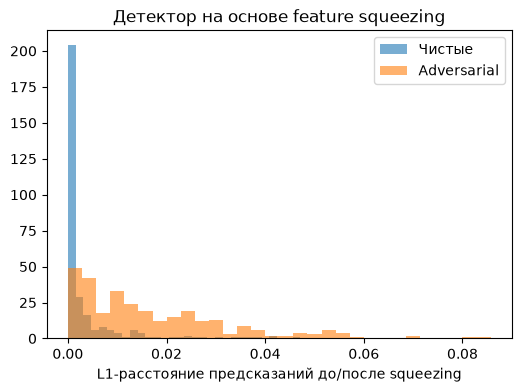

In [2]:

def squeeze(x, bit_depth=4):
    levels = 2**bit_depth - 1
    return torch.round(x*levels)/levels

def detect_via_squeezing(model, x, threshold=0.3):
    p1 = F.softmax(model(x), dim=1)
    p2 = F.softmax(model(squeeze(x)), dim=1)
    l1_dist = (p1-p2).abs().sum(dim=1)
    return (l1_dist > threshold), l1_dist

flag_clean, dist_clean = detect_via_squeezing(model, clean_batch)
flag_adv, dist_adv = detect_via_squeezing(model, adv_batch)

print(f"Доля чистых примеров, ошибочно помеченных как атака (false positive rate): {flag_clean.float().mean():.2%}")
print(f"Доля adversarial примеров, верно обнаруженных (true positive rate): {flag_adv.float().mean():.2%}")

plt.figure(figsize=(6,4))
plt.hist(dist_clean.detach().numpy(), bins=30, alpha=0.6, label='Чистые')
plt.hist(dist_adv.detach().numpy(), bins=30, alpha=0.6, label='Adversarial')
plt.xlabel("L1-расстояние предсказаний до/после squeezing"); plt.legend()
plt.title("Детектор на основе feature squeezing")
plt.savefig('output/notebooks/lec13_detector.png', dpi=120)
plt.show()
